<a href="https://colab.research.google.com/github/codeshujaa/Plasmodium-Life-Stage-Detection/blob/main/Plasmodium_Life_Stage_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:0000:01


In [ ]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
import torch
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from torch.utils.tensorboard import SummaryWriter
from huggingface_hub import HfApi, login
from ultralytics import YOLO

2026-03-18 15:37:17.442370: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773848237.639796      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773848237.695960      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773848238.137312      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773848238.137356      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773848238.137359      55 computation_placer.cc:177] computation placer alr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(f"Number of GPUs available: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"  Total Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB")

Number of GPUs available: 1
GPU 0: Tesla P100-PCIE-16GB
  Total Memory: 17.06 GB


In [ ]:
HF_TOKEN =
HF_REPO_ID =

login(token=HF_TOKEN)

In [ ]:
EXCEL_PATH      = '/kaggle/input/datasets/colabsandbox/phase1-malaria/archive/malaria project/LifeStages.xlsx'
IMAGES_DIR      = '/kaggle/input/datasets/colabsandbox/phase1-malaria/archive/malaria project/Giemsa stained images'
DATASET_DIR     = '/kaggle/working/yolo_dataset'
RUNS_DIR        = '/kaggle/working/runs/plasmodium'
WEIGHTS_DIR     = '/kaggle/working/yolo26_plasmodium'

CLASS_NAMES     = ['Ring', 'Schizont', 'Trophozoite']
CLASS_TO_ID     = {name: idx for idx, name in enumerate(CLASS_NAMES)}

CROP_SIZES      = {'Ring': 80, 'Trophozoite': 110, 'Schizont': 150}

TRAIN_RATIO     = 0.70
VAL_RATIO       = 0.15
TEST_RATIO      = 0.15
RANDOM_STATE    = 42
IMAGE_SIZE      = 512
EPOCHS          = 80
BATCH_SIZE      = 2

In [ ]:
# Load annotations
stage_mapping = {
    'R': 'Ring', 'LR-ET': 'Ring',
    'LT': 'Trophozoite', 'MT': 'Trophozoite',
    'Esch': 'Schizont', 'Lsch': 'Schizont', 'Seg': 'Schizont'
}

df = pd.read_excel(EXCEL_PATH)
df['stage'] = df['stage'].map(stage_mapping)
df = df.dropna(subset=['stage'])
df = df.drop_duplicates(subset=['imageName', 'center_x', 'center_y'])
df['full_path'] = df['imageName'].apply(lambda x: os.path.join(IMAGES_DIR, x))
df = df[df['full_path'].apply(os.path.exists)].copy()

print(f"Total annotations: {len(df)}")
print(df['stage'].value_counts())

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Total annotations: 2889
stage
Schizont       1356
Ring            834
Trophozoite     699
Name: count, dtype: int64


In [ ]:
# Split at image
image_stage = df.groupby('imageName')['stage'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()

image_paths = df[['imageName', 'full_path']].drop_duplicates()
image_stage = image_stage.merge(image_paths, on='imageName')

train_imgs, temp_imgs = train_test_split(
    image_stage, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=image_stage['stage'], random_state=RANDOM_STATE
)

val_imgs, test_imgs = train_test_split(
    temp_imgs, test_size=0.50,
    stratify=temp_imgs['stage'], random_state=RANDOM_STATE
)

print(f"Train: {len(train_imgs)}  Val: {len(val_imgs)}  Test: {len(test_imgs)}")

Train: 569  Val: 122  Test: 122


In [ ]:
# balance training distribution
ring_imgs = train_imgs[train_imgs['stage'] == 'Ring']

train_imgs = pd.concat([train_imgs, ring_imgs, ring_imgs])
train_imgs = train_imgs.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Train after Ring oversampling: {len(train_imgs)}")
print(train_imgs['stage'].value_counts())

Train after Ring oversampling: 841
stage
Ring           408
Schizont       308
Trophozoite    125
Name: count, dtype: int64


In [ ]:
#  YOLO format
shutil.rmtree(DATASET_DIR, ignore_errors=True)

for split in ['train', 'val', 'test']:
    os.makedirs(f'{DATASET_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{DATASET_DIR}/labels/{split}', exist_ok=True)

In [ ]:
#  YOLO bounding boxes
def write_annotations(image_df, annotations_df, split):
    for _, row in image_df.iterrows():
        img = cv2.imread(row['full_path'])
        img_h, img_w = img.shape[:2]

        shutil.copy(
            row['full_path'],
            f"{DATASET_DIR}/images/{split}/{row['imageName']}"
        )

        label_name = os.path.splitext(row['imageName'])[0] + '.txt'
        label_path = f"{DATASET_DIR}/labels/{split}/{label_name}"

        img_anns = annotations_df[annotations_df['imageName'] == row['imageName']]

        with open(label_path, 'w') as f:
            for _, ann in img_anns.iterrows():
                crop = CROP_SIZES[ann['stage']]
                cx, cy = ann['center_x'], ann['center_y']

                xmin = max(0, cx - crop // 2)
                ymin = max(0, cy - crop // 2)
                xmax = min(img_w, cx + crop // 2)
                ymax = min(img_h, cy + crop // 2)

                x_center = ((xmin + xmax) / 2) / img_w
                y_center = ((ymin + ymax) / 2) / img_h
                width    = (xmax - xmin) / img_w
                height   = (ymax - ymin) / img_h

                class_id = CLASS_TO_ID[ann['stage']]
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

In [ ]:
# train, val and test annotation
write_annotations(train_imgs, df, 'train')
write_annotations(val_imgs,   df, 'val')
write_annotations(test_imgs,  df, 'test')

print("All splits written")

All splits written


In [ ]:
# YOLO dataset splits
yaml_content = f"""path: {DATASET_DIR}
train: images/train
val:   images/val
test:  images/test

nc: 3
names: ['Ring', 'Schizont', 'Trophozoite']
"""

with open(f'{DATASET_DIR}/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml written")

data.yaml written


In [ ]:
# TensorBoard
os.makedirs(RUNS_DIR, exist_ok=True)
writer = SummaryWriter(log_dir=RUNS_DIR)
print(f"TensorBoard logging to: {RUNS_DIR}")

TensorBoard logging to: /kaggle/working/runs/plasmodium


In [ ]:
# Load pretrained YOLO26m weights
gc.collect()
torch.cuda.empty_cache()

model = YOLO('yolo26m.pt')
print("Model loaded")

Model loaded


In [ ]:
# Train  hyperparameters
results = model.train(
    data        = f'{DATASET_DIR}/data.yaml',
    epochs      = EPOCHS,
    imgsz       = IMAGE_SIZE,
    batch       = BATCH_SIZE,
    lr0         = 5e-5,
    lrf         = 0.001,
    optimizer   = 'AdamW',
    weight_decay= 0.01,
    cos_lr      = True,
    patience    = 30,
    cls         = 3.0,
    box         = 5.0,
    device      = 0,
    workers     = 2,
    project     = '/kaggle/working',
    name        = 'yolo26_plasmodium',
    exist_ok    = True,
    amp         = True,
    hsv_h       = 0.02,
    hsv_s       = 0.8,
    hsv_v       = 0.5,
    degrees     = 15,
    translate   = 0.15,
    scale       = 0.6,
    shear       = 8,
    flipud      = 0.5,
    fliplr      = 0.5,
    mosaic      = 1.0,
    mixup       = 0.1,
    copy_paste  = 0.1,
    val         = True,
    plots       = True,
    save        = True,
    cache       = False
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=5.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_plasmodium, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True

In [ ]:
history = pd.read_csv(f'/kaggle/working/yolo26_plasmodium/results.csv')
history.columns = history.columns.str.strip()

for _, row in history.iterrows():
    epoch = int(row['epoch'])
    writer.add_scalar('Loss/train_box',  row['train/box_loss'],     epoch)
    writer.add_scalar('Loss/train_cls',  row['train/cls_loss'],     epoch)
    writer.add_scalar('Loss/train_dfl',  row['train/dfl_loss'],     epoch)
    writer.add_scalar('Loss/val_box',    row['val/box_loss'],       epoch)
    writer.add_scalar('Loss/val_cls',    row['val/cls_loss'],       epoch)
    writer.add_scalar('mAP/mAP50',       row['metrics/mAP50(B)'],   epoch)
    writer.add_scalar('mAP/mAP50_95',    row['metrics/mAP50-95(B)'],epoch)
    writer.add_scalar('Precision',       row['metrics/precision(B)'],epoch)
    writer.add_scalar('Recall',          row['metrics/recall(B)'],  epoch)

writer.flush()
writer.close()
print("TensorBoard events written")

TensorBoard events written


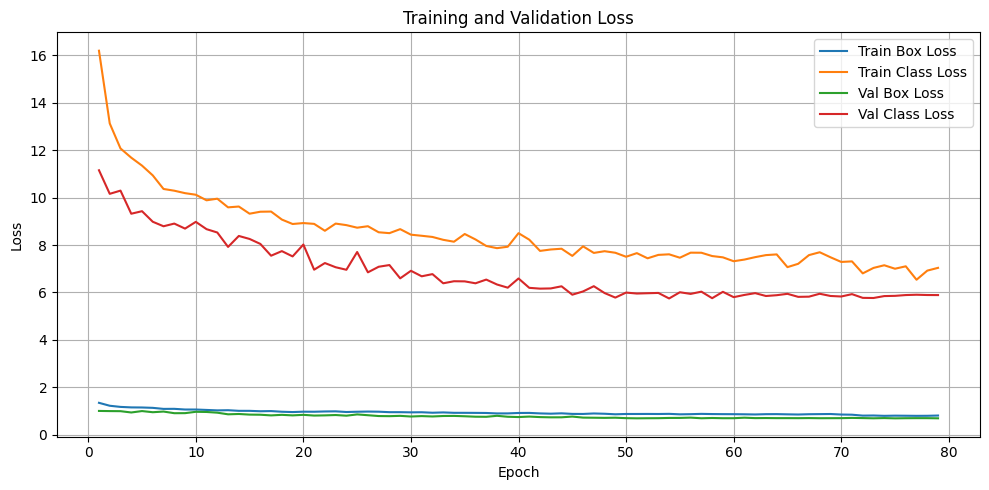

In [ ]:
# Display training and validation loss curves
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history['epoch'], history['train/box_loss'], label='Train Box Loss')
ax.plot(history['epoch'], history['train/cls_loss'], label='Train Class Loss')
ax.plot(history['epoch'], history['val/box_loss'],   label='Val Box Loss')
ax.plot(history['epoch'], history['val/cls_loss'],   label='Val Class Loss')

ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

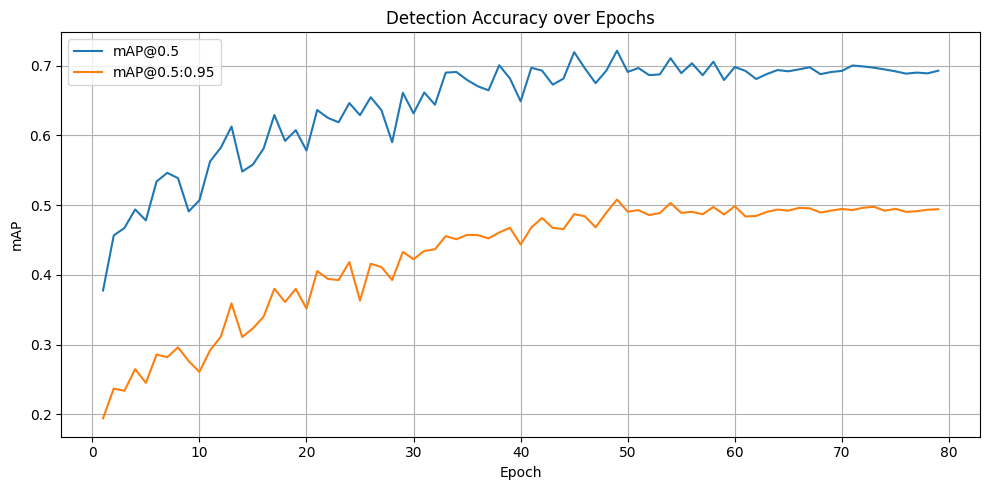

In [ ]:
# Display mAP@0.5 and mAP@0.5:0.95 over training epochs
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history['epoch'], history['metrics/mAP50(B)'],    label='mAP@0.5')
ax.plot(history['epoch'], history['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')

ax.set_title('Detection Accuracy over Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Load best checkpoint
gc.collect()
torch.cuda.empty_cache()

best_model = YOLO(f'/kaggle/working/yolo26_plasmodium/weights/best.pt')

val_results = best_model.val(
    data   = f'{DATASET_DIR}/data.yaml',
    split  = 'val',
    imgsz  = IMAGE_SIZE,
    batch  = BATCH_SIZE,
    conf   = 0.15,
    iou    = 0.5,
    device = 0,
    plots  = True,
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5534.1±1169.2 MB/s, size: 1995.2 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 122 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 122/122 51.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 20.2it/s 3.0s0.0s
                   all        122        439      0.663      0.697       0.71      0.513
                  Ring         63        118      0.634      0.559      0.604      0.405
              Schizont         99        215      0.748       0.91       0.88      0.659
           Trophozoite         66        106      0.606      0.623      0.646      0.476
Speed: 0.8ms preprocess, 15.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /kag

In [ ]:
# Match predictions
val_images_dir = f'{DATASET_DIR}/images/val'
val_labels_dir = f'{DATASET_DIR}/labels/val'

y_true, y_pred, y_scores = [], [], []

for img_file in sorted(os.listdir(val_images_dir)):
    img_path   = os.path.join(val_images_dir, img_file)
    label_path = os.path.join(val_labels_dir, os.path.splitext(img_file)[0] + '.txt')

    gt_classes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            gt_classes.append(int(parts[0]))

    preds = best_model.predict(img_path, conf=0.15, verbose=False, device=0)

    pred_classes = []
    pred_confs   = []
    for result in preds:
        for box in result.boxes:
            pred_classes.append(int(box.cls))
            pred_confs.append(float(box.conf))

    for gt, pc, conf in zip(gt_classes, pred_classes, pred_confs):
        scores = [0.0, 0.0, 0.0]
        scores[pc] = conf
        y_true.append(gt)
        y_pred.append(pc)
        y_scores.append(scores)

print(f"Matched pairs: {len(y_true)}")

Matched pairs: 434


In [ ]:
# Print per-class precision, recall and F1 scores
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

        Ring       0.68      0.57      0.62       115
    Schizont       0.70      0.76      0.73       214
 Trophozoite       0.42      0.42      0.42       105

    accuracy                           0.63       434
   macro avg       0.60      0.58      0.59       434
weighted avg       0.63      0.63      0.62       434



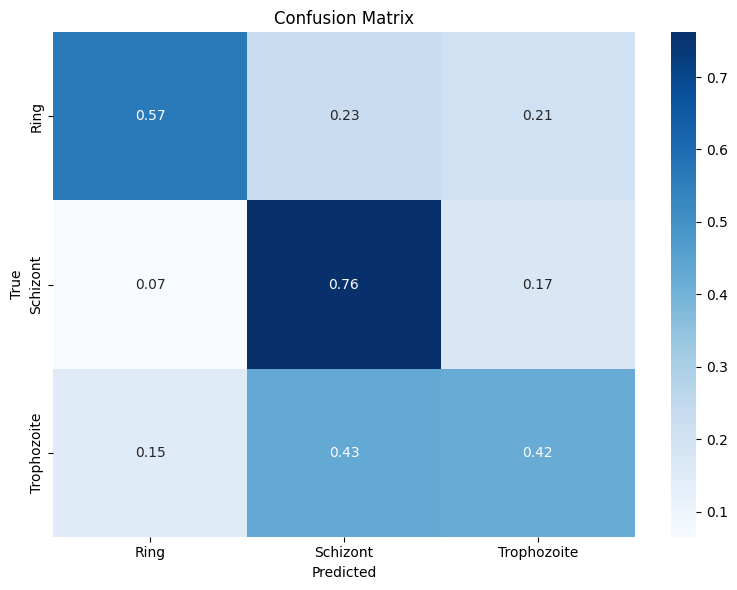

In [ ]:
#  confusion matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)

ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

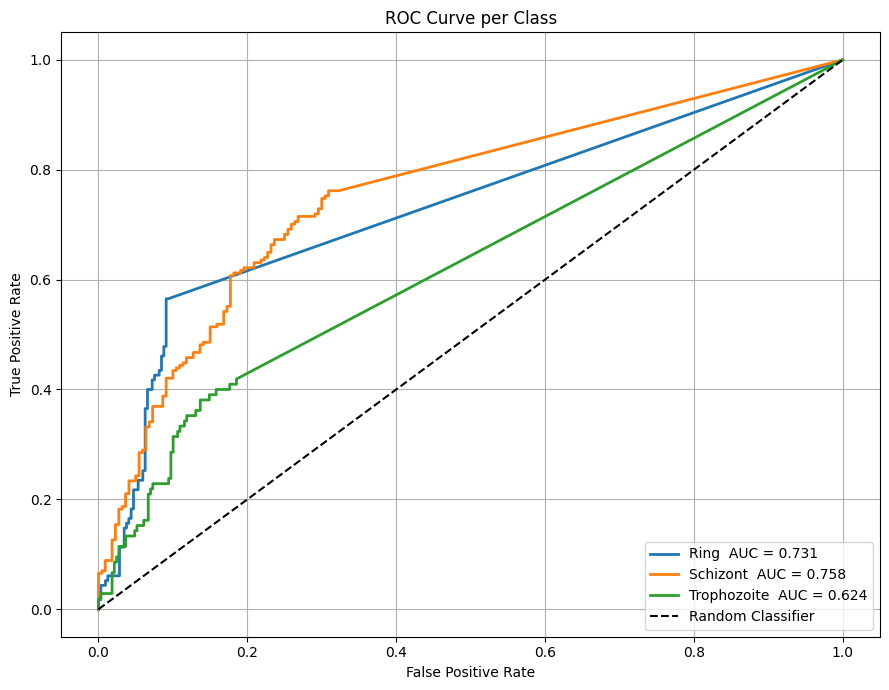

In [ ]:
#  ROC curves with AUC scores
y_true_bin   = label_binarize(y_true, classes=[0, 1, 2])
y_scores_arr = np.array(y_scores)

fig, ax = plt.subplots(figsize=(9, 7))
colors  = cycle(['#1f77b4', '#ff7f0e', '#2ca02c'])

for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores_arr[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{CLASS_NAMES[i]}  AUC = {roc_auc:.3f}')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_title('ROC Curve per Class')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

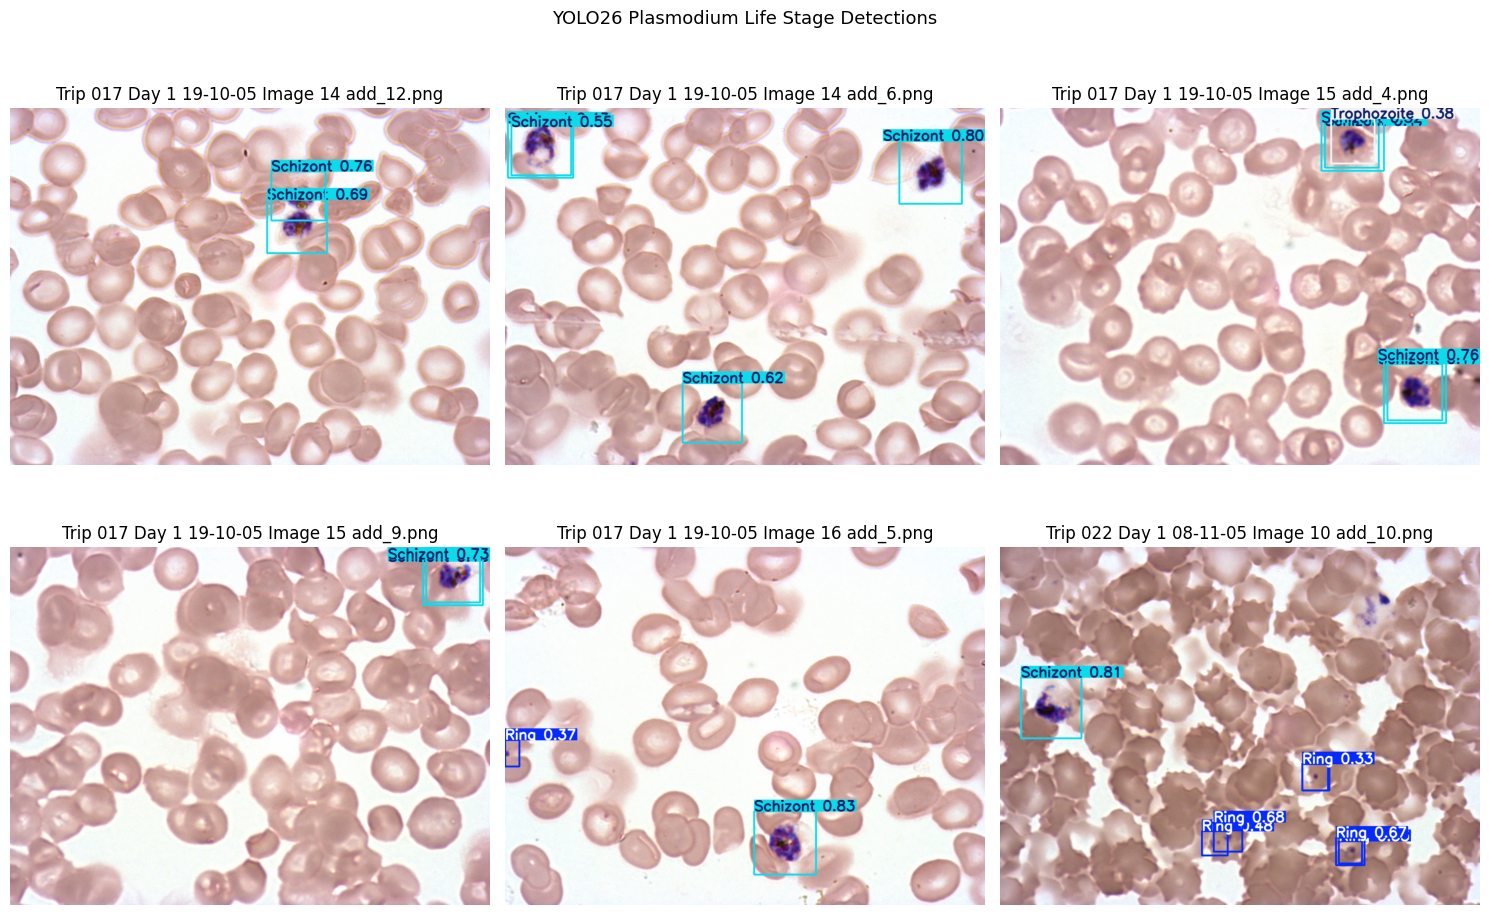

In [ ]:
# Visualize model predictions on the first 6 validation images
sample_files = sorted(os.listdir(val_images_dir))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_file in enumerate(sample_files):
    img_path = os.path.join(val_images_dir, img_file)
    result   = best_model.predict(img_path, conf=0.15, verbose=False, device=0)[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

    axes[idx].imshow(annotated)
    axes[idx].set_title(img_file)
    axes[idx].axis('off')

plt.suptitle('YOLO26 Plasmodium Life Stage Detections', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
test_results = best_model.val(
    data   = f'{DATASET_DIR}/data.yaml',
    split  = 'test',
    imgsz  = IMAGE_SIZE,
    batch  = BATCH_SIZE,
    conf   = 0.15,
    iou    = 0.5,
    device = 0
)

print(f"Test mAP@0.5:     {test_results.box.map50:.4f}")
print(f"Test mAP@0.5:0.95: {test_results.box.map:.4f}")

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4223.3±956.0 MB/s, size: 1933.1 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/test... 122 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 122/122 91.2it/s 1.3s0.1s
val: New cache created: /kaggle/working/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 19.5it/s 3.1s0.0s
                   all        122        436      0.666      0.753      0.735      0.513
                  Ring         66        127      0.623      0.586      0.551      0.377
              Schizont         94        214      0.733      0.937      0.917      0.646
           Trophozoite         61         95      0.641      0.737      0.737      0.516
Speed: 0.7ms preprocess, 13.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /kaggle/working/runs/

In [ ]:
# Push to Hugging Face
api = HfApi()

api.create_repo(
    repo_id = HF_REPO_ID,
    token   = HF_TOKEN,
    exist_ok= True
)

api.upload_folder(
    folder_path = RUNS_DIR,
    repo_id     = HF_REPO_ID,
    path_in_repo= 'runs/plasmodium',
    token       = HF_TOKEN,
)

print(f"TensorBoard events uploaded to: https://huggingface.co/{HF_REPO_ID}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

TensorBoard events uploaded to: https://huggingface.co/codeshujaaa/kenyanmalarai-detect


In [ ]:
api.upload_file(
    path_or_fileobj = f'/kaggle/working/yolo26_plasmodium/weights/best.pt',
    path_in_repo    = 'weights/best.pt',
    repo_id         = HF_REPO_ID,
    token           = HF_TOKEN,
)

print(f"Best model uploaded to: https://huggingface.co/{HF_REPO_ID}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Best model uploaded to: https://huggingface.co/codeshujaaa/kenyanmalarai-detect
